<a href="https://colab.research.google.com/github/anunyathpn/Data-warehouse/blob/main/Part1_%E0%B8%AD%E0%B8%99%E0%B8%B1%E0%B8%8D%E0%B8%8D%E0%B8%B2_%E0%B8%97%E0%B8%AD%E0%B8%87%E0%B8%9B%E0%B8%99.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **อนัญญา ทองปน 673020268-9**


---
# Part 1: Social Listening Warm-up
*งานเดี่ยว — ทุกคนต้องทำและส่งของตนเอง ไม่ต้องนำเสนอ (10 คะแนน)*

ใช้ข้อมูลโพสต์สาธารณะจาก **Bluesky**  
https://huggingface.co/datasets/alpindale/two-million-bluesky-posts

ใช้เพียง **1–3 ไฟล์** ก็พอ ไม่จำเป็นต้องโหลดทั้ง dataset

ฟิลด์ที่มี เช่น `text`, `created_at`, `author`, `uri`, `has_images`, `reply_to`, `predicted_language`

## ตอบ 4 คำถามหลัก

1. **คนโพสต์เมื่อไร:** จำนวนโพสต์ ช่วงเวลาที่ข้อมูลครอบคลุม และชั่วโมงที่โพสต์มากที่สุด
2. **ใช้ภาษาอะไร:** รายงานภาษาหลักและสัดส่วน เพื่อบอกว่าถ้าทำคอนเทนต์ควรรองรับภาษาใด
3. **คนพูดถึงอะไร:** หา hashtag หรือคำ/วลีเด่นที่น่าสนใจ และยกตัวอย่างข้อความจริงประกอบ
4. **ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้:** สร้าง visualization 1 รูป แล้วเขียนข้อจำกัด 3–5 บรรทัด

> Part 1 เป็น warm-up ไม่ต้องทำ influencer analysis หรือ reply-network เว้นแต่สนใจทำเพิ่มเอง

In [1]:
# ติดตั้ง library ที่จำเป็น (Colab รันครั้งแรกครั้งเดียว)
!pip install -q huggingface_hub langdetect

import json
import os
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from langdetect import DetectorFactory, detect
from huggingface_hub import hf_hub_download, list_repo_files

RANDOM_SEED = 42
DetectorFactory.seed = RANDOM_SEED

DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)

REPO_ID = "alpindale/two-million-bluesky-posts"
TARGET_FILES = [
    "posts_20241127_120237.jsonl",
    "posts_20241127_143458.jsonl",
]


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 15.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
# หาไฟล์จาก repository แล้วดาวน์โหลดเฉพาะ 2 ไฟล์ที่ใช้
repo_files = list_repo_files(REPO_ID, repo_type="dataset")

selected_files = []
for target in TARGET_FILES:
    matched = [f for f in repo_files if os.path.basename(f) == target]
    if matched:
        selected_files.append(matched[0])

# ถ้าชื่อไฟล์ใน repo เปลี่ยน ให้ใช้ JSONL 2 ไฟล์แรกแทน
if len(selected_files) < 2:
    selected_files = [f for f in repo_files if f.endswith(".jsonl")][:2]

file_paths = [
    hf_hub_download(
        repo_id=REPO_ID,
        filename=f,
        repo_type="dataset",
        local_dir=DATA_DIR,
    )
    for f in selected_files
]

def iter_jsonl(path):
    """อ่านไฟล์ JSONL ทีละบรรทัด เพื่อไม่ใช้ RAM เกินจำเป็น"""
    with open(path, encoding="utf-8") as f:
        for line in f:
            try:
                yield json.loads(line)
            except json.JSONDecodeError:
                continue

rows = []
for path in file_paths:
    rows.extend(iter_jsonl(path))

df = pd.DataFrame(rows)

print("ไฟล์ที่ใช้:")
for f in selected_files:
    print("-", f)
print(f"\nจำนวนแถวที่อ่านได้ทั้งหมด: {len(df):,} โพสต์")
print("คอลัมน์:", list(df.columns))


posts_20241127_120237.jsonl: reconstructing file:   0%|          |  0.00B / 39.4MB            

posts_20241127_120237.jsonl: downloading bytes:           |  0.00B            

posts_20241127_143458.jsonl: reconstructing file:   0%|          |  0.00B / 38.5MB            

posts_20241127_143458.jsonl: downloading bytes:           |  0.00B            

ไฟล์ที่ใช้:
- posts_20241127_120237.jsonl
- posts_20241127_143458.jsonl

จำนวนแถวที่อ่านได้ทั้งหมด: 200,000 โพสต์
คอลัมน์: ['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to']


## 1) คนโพสต์เมื่อไร

In [3]:
# แปลงเวลาเป็น datetime แบบ UTC และตัดแถวที่เวลาใช้ไม่ได้
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce", utc=True)

total_before = len(df)
invalid_time = df["created_at"].isna().sum()
df_time = df.dropna(subset=["created_at"]).copy()

hourly = df_time["created_at"].dt.hour.value_counts().sort_index()
peak_hour = int(hourly.idxmax())
peak_count = int(hourly.max())

print(f"จำนวนโพสต์ทั้งหมดก่อนตัดเวลาเสีย: {total_before:,}")
print(f"เวลาใช้ไม่ได้/ว่าง: {invalid_time:,}")
print(f"จำนวนโพสต์ที่ใช้วิเคราะห์เวลาได้: {len(df_time):,}")
print(f"ช่วงเวลาที่ข้อมูลครอบคลุม: {df_time['created_at'].min()} ถึง {df_time['created_at'].max()}")
print(f"ชั่วโมงที่โพสต์มากที่สุด: {peak_hour:02d}:00-{peak_hour:02d}:59 UTC ({peak_count:,} โพสต์)")


จำนวนโพสต์ทั้งหมดก่อนตัดเวลาเสีย: 200,000
เวลาใช้ไม่ได้/ว่าง: 9,095
จำนวนโพสต์ที่ใช้วิเคราะห์เวลาได้: 190,905
ช่วงเวลาที่ข้อมูลครอบคลุม: 2009-01-15 20:11:28+00:00 ถึง 2024-11-28 07:18:20.503000+00:00
ชั่วโมงที่โพสต์มากที่สุด: 12:00-12:59 UTC (92,758 โพสต์)


**สรุปคำตอบข้อ 1**

จาก 200,000 โพสต์ มี 190,905 โพสต์ที่สามารถใช้วิเคราะห์เวลาได้ โดยข้อมูลครอบคลุมช่วง 15 มกราคม 2009 ถึง 28 พฤศจิกายน 2024 (UTC) และช่วงเวลาที่พบโพสต์มากที่สุดคือ 12:00–12:59 UTC จำนวน 92,758 โพสต์  

อย่างไรก็ตาม การที่โพสต์จำนวนมากกระจุกตัวในบางช่วงเวลาอาจเกิดจากลักษณะของชุดข้อมูลหรือกระบวนการเก็บข้อมูล จึงไม่ควรสรุปทันทีว่า 12:00 UTC คือช่วงเวลาที่ผู้ใช้ Bluesky ทั่วโลกใช้งานมากที่สุด

## 2) ใช้ภาษาอะไร

In [6]:
# สุ่ม 10,000 โพสต์มาตรวจภาษา เพื่อให้ประมวลผลเร็วขึ้น
sample_df = df["text"].dropna().sample(
    n=min(10000, df["text"].dropna().shape[0]),
    random_state=42
).to_frame()

def detect_language(text):
    if not isinstance(text, str) or not text.strip():
        return "unknown"
    try:
        return detect(text)
    except Exception:
        return "unknown"

sample_df["language"] = sample_df["text"].apply(detect_language)

LANG_NAMES = {
    "en": "English",
    "ja": "Japanese",
    "pt": "Portuguese",
    "es": "Spanish",
    "fr": "French",
    "de": "German",
    "ko": "Korean",
    "nl": "Dutch",
    "it": "Italian",
    "th": "Thai",
    "zh-cn": "Chinese (Simplified)",
    "zh-tw": "Chinese (Traditional)",
    "unknown": "Unknown / Symbols"
}

language_summary = sample_df["language"].value_counts().reset_index()
language_summary.columns = ["language_code", "post_count"]

language_summary["language"] = language_summary["language_code"].map(
    lambda x: LANG_NAMES.get(x, f"Other ({x})")
)

language_summary["percentage"] = (
    language_summary["post_count"] / len(sample_df) * 100
).round(2)

display(language_summary[["language", "post_count", "percentage"]].head(10))

,language,post_count,percentage
0,English,5122,51.22
1,Japanese,1326,13.26
2,Unknown / Symbols,604,6.04
3,Portuguese,435,4.35
4,Spanish,419,4.19
5,French,346,3.46
6,German,281,2.81
7,Korean,199,1.99
8,Italian,115,1.15
9,Dutch,96,0.96


**สรุปคำตอบข้อ 2**

จากตัวอย่าง 10,000 โพสต์ ภาษาอังกฤษเป็นภาษาหลัก คิดเป็น 51.22% รองลงมาคือภาษาญี่ปุ่น 13.26% และข้อความที่ตรวจไม่ชัดเจนหรือเป็นสัญลักษณ์อยู่ที่ 6.04%


ถ้าต้องทำคอนเทนต์จากข้อมูลชุดนี้ ควรใช้ ภาษาอังกฤษเป็นภาษาหลัก และพิจารณารองรับ ภาษาญี่ปุ่นเป็นภาษาที่สอง เนื่องจากมีสัดส่วนสูงรองลงมาอย่างชัดเจน


อย่างไรก็ตาม การตรวจภาษาอัตโนมัติอาจมีความคลาดเคลื่อน โดยเฉพาะข้อความสั้น อีโมจิ หรือข้อความที่มีหลายภาษา และผลลัพธ์นี้มาจากการสุ่มตัวอย่าง 10,000 โพสต์ จึงควรใช้เพื่อดูแนวโน้มของภาษาในข้อมูล มากกว่าการสรุปแทนโพสต์ทั้งหมดแบบเด็ดขาด


## 3) คนพูดถึงอะไร

In [7]:
def extract_hashtags(text):
    if not isinstance(text, str):
        return []
    return re.findall(r"#[\w\u0E00-\u0E7F_]+", text, flags=re.UNICODE)

all_hashtags = [
    tag.lower()
    for text in df["text"].dropna()
    for tag in extract_hashtags(text)
]

top_hashtags = Counter(all_hashtags).most_common(10)
hashtag_df = pd.DataFrame(top_hashtags, columns=["hashtag", "count"])

# ยกตัวอย่างข้อความจริง 1 โพสต์ต่อ hashtag
examples = []
for tag, count in top_hashtags:
    sample = (
        df.loc[df["text"].astype(str).str.contains(re.escape(tag), case=False, na=False), "text"]
        .drop_duplicates()
        .head(1)
        .tolist()
    )
    examples.append(" ".join(sample[0].split()) if sample else "-")

hashtag_df["example_post"] = examples
display(hashtag_df)


,hashtag,count,example_post
0,#art,516,100 Artworks From the Top Digital Artists in t...
1,#booksky,382,Choose 20 books that have stayed with you or i...
2,#bastien,349,"L'enfant, qui avait 3 ans et demi, est mort le..."
3,#nsfw,270,Mm baby I had a dream where a thousand of your...
4,#books,262,Choose 20 books that have stayed with you or i...
5,#bookchallenge,254,Choose 20 books that have stayed with you or i...
6,#photography,251,Short-eared Owl at the Shawangunk Grasslands 🪶...
7,#cahuzac,238,Puisque l'ayant-droit économique reste le même...
8,#oc,185,#イラスト #ilustration #オリキャラ #OC ⚫️
9,#bluesky,145,What is this place? #bluesky


**สรุปคำตอบข้อ 3**

Hashtag ที่พบมากที่สุดคือ #art จำนวน 516 ครั้ง รองลงมาคือ #booksky จำนวน 382 ครั้ง และ #bastien จำนวน 349 ครั้ง


เมื่อดูจาก hashtag ที่อยู่ในอันดับต้น ๆ พบว่ามีกลุ่มคำเกี่ยวกับ หนังสือและกิจกรรมการอ่าน เช่น #booksky, #books และ #bookchallenge ค่อนข้างเด่น นอกจากนี้ยังพบ hashtag ที่เกี่ยวกับ งานสร้างสรรค์และภาพถ่าย เช่น #art และ #photography


อย่างไรก็ตาม ผลลัพธ์นี้มาจากข้อมูลเพียง 2 ไฟล์ จึงสะท้อนหัวข้อที่เด่นในข้อมูลที่นำมาวิเคราะห์เท่านั้น และไม่ควรสรุปว่าเป็นหัวข้อยอดนิยมของผู้ใช้ Bluesky ทั้งแพลตฟอร์ม

## 4) ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้

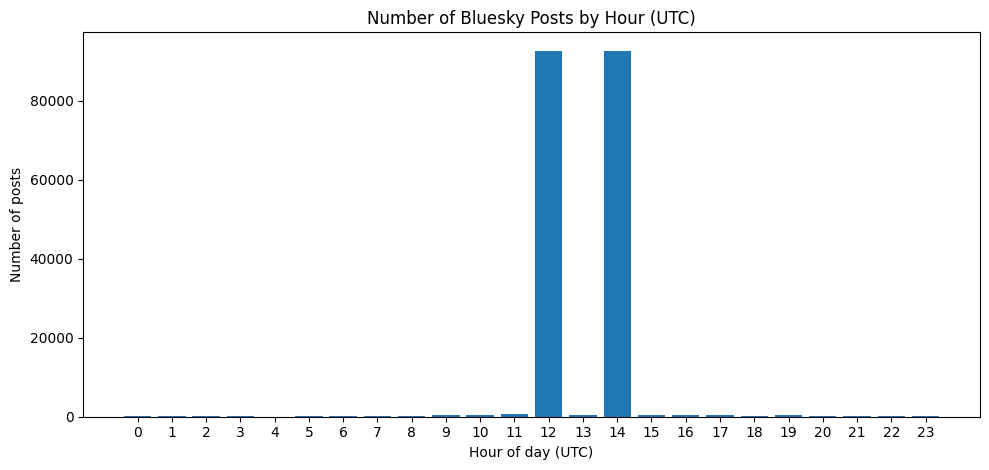

In [8]:
# Visualization: จำนวนโพสต์แยกตามชั่วโมง
hourly_df = hourly.reindex(range(24), fill_value=0)

plt.figure(figsize=(10, 4.8))
plt.bar(hourly_df.index, hourly_df.values)
plt.title("Number of Bluesky Posts by Hour (UTC)")
plt.xlabel("Hour of day (UTC)")
plt.ylabel("Number of posts")
plt.xticks(range(24))
plt.tight_layout()
plt.show()


### **ตีความ Visualization และข้อจำกัด**

ตีความ Visualization และข้อจำกัด
กราฟแสดงว่าจำนวนโพสต์ในข้อมูลชุดนี้กระจุกตัวมากที่ช่วง 12:00 UTC และ 14:00 UTC เมื่อเทียบกับชั่วโมงอื่นอย่างชัดเจน จึงอาจได้รับอิทธิพลจาก วิธีและช่วงเวลาที่เก็บข้อมูล และไม่ควรตีความว่าเป็นพฤติกรรมการใช้งานรายวันของผู้ใช้ Bluesky ทั้งหมดโดยตรง


**ข้อมูลนี้บอกได้**
- ใน 2 ไฟล์ที่เลือก มีจำนวนโพสต์มากน้อยอย่างไรในแต่ละชั่วโมง และช่วงเวลาใดมีข้อมูลหนาแน่น
- ภาษาหลักที่พบจากตัวอย่างข้อความ และ hashtag หรือประเด็นที่พบซ้ำบ่อย


**ข้อมูลนี้ยังบอกไม่ได้**
- ไม่สามารถสรุปว่าเป็นพฤติกรรมของผู้ใช้ Bluesky ทั้งแพลตฟอร์ม เพราะใช้เพียง 2 ไฟล์จากชุดข้อมูลขนาดใหญ่
- เวลาเป็น UTC และไม่มีข้อมูลตำแหน่งประเทศของผู้โพสต์ จึงไม่สามารถระบุได้ว่าเวลาใดคือช่วงที่ผู้ใช้ในแต่ละประเทศใช้งานมากที่สุด
- ไม่มีข้อมูล Engagement เช่น Like หรือ Repost จึงไม่สามารถบอกได้ว่าโพสต์หรือ hashtag ใดได้รับความนิยมมากที่สุดจริง
- การวิเคราะห์ภาษาใช้การสุ่มตัวอย่าง 10,000 โพสต์ และการตรวจภาษาอัตโนมัติอาจคลาดเคลื่อนกับข้อความสั้น หลายภาษา สแลง หรืออีโมจิ ส่วนการวิเคราะห์ hashtag ใช้ข้อมูล 200,000 โพสต์ทั้งหมด


##  **สรุปสั้น ๆ ถึงลูกค้า**
1. จากข้อมูล **2 ไฟล์ จำนวน 200,000 โพสต์** พบว่า มี **190,905 โพสต์** ที่สามารถนำมาใช้วิเคราะห์ช่วงเวลาได้

2. จำนวนโพสต์มีการกระจุกตัวสูงในช่วง **12:00 และ 14:00 UTC** จึงควรระวังว่ารูปแบบดังกล่าวอาจได้รับอิทธิพลจาก **ช่วงเวลาหรือวิธีการเก็บข้อมูล**

3. จากการสุ่มตรวจภาษา **10,000 โพสต์** พบว่า **ภาษาอังกฤษเป็นภาษาหลัก 51.22%** และ **ภาษาญี่ปุ่นเป็นอันดับสอง 13.26%** ดังนั้น หากนำข้อมูลไปใช้ทำคอนเทนต์ ควรใช้อังกฤษเป็นภาษาหลักและพิจารณารองรับภาษาญี่ปุ่นเพิ่มเติม

4. Hashtag ที่พบเด่น ได้แก่ **#art, #booksky, #books และ #photography** ซึ่งสะท้อนประเด็นเกี่ยวกับ **ศิลปะ หนังสือ การอ่าน และคอนเทนต์สร้างสรรค์**

5. ผลลัพธ์นี้เหมาะสำหรับใช้เป็น **Social Listening เบื้องต้น** แต่ยังไม่ควรนำไปสรุปแทนผู้ใช้ Bluesky ทั้งหมด เนื่องจากใช้ข้อมูลเพียง **2 ไฟล์** และไม่มีข้อมูล **Engagement** เช่น Like หรือ Repost มาประกอบ

###**แหล่งข้อมูล**
- Hugging Face Dataset: `alpindale/two-million-bluesky-posts`
- ชุดข้อมูลประกอบด้วยโพสต์สาธารณะจาก Bluesky และ metadata เช่น `text`, `created_at`, `author`, `uri`, `has_images`, `reply_to`
